# ENTREGA 2 - MODELADO Y EVALUACION

En esta seccion se realiza el preprocesamiento, entrenamiento, ajuste de hiperparametros y evaluacion de los 4 modelos: **GaussianNB, DecisionTree, RandomForest y SVM**.

Metrica principal: **AUROC + Recall (Sensibilidad)** — minizar Falsos Negativos en contexto hospitalario.

## CELDA 0 — Preprocesamiento completo

In [25]:
# ============================================================
# CELDA 0 - PREPROCESAMIENTO
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report, roc_curve,
                             average_precision_score)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Separar features y target
X_raw = df.drop(columns=['Reingreso_30_Dias'])
y     = df['Reingreso_30_Dias'].copy()

# Corregir creatinina negativa (si no se hizo antes)
X_raw['Nivel_Creatinina'] = X_raw['Nivel_Creatinina'].apply(
    lambda v: X_raw['Nivel_Creatinina'].median() if v < 0 else v
)

# Eliminar columna auxiliar si existe
if 'Severidad_Cat' in X_raw.columns:
    X_raw = X_raw.drop(columns=['Severidad_Cat'])

# One-Hot Encoding para variables categoricas
X_encoded = pd.get_dummies(X_raw, drop_first=True)
feature_names = X_encoded.columns.tolist()

# Escalar con StandardScaler
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded),
                        columns=feature_names,
                        index=X_encoded.index)

print(f"X shape: {X_scaled.shape}  |  y shape: {y.shape}")
print(f"Distribucion target: 1 (Reingreso) = {y.mean()*100:.1f}%  |  0 = {(1-y.mean())*100:.1f}%")
print(f"Variables tras encoding: {X_scaled.shape[1]}")


X shape: (18000, 30)  |  y shape: (18000,)
Distribucion target: 1 (Reingreso) = 74.2%  |  0 = 25.8%
Variables tras encoding: 30


## CELDA 1 — Division Estratificada Train / Test

**Justificacion tecnica:** Con 18,000 registros y desbalance 74/26, usamos `stratify=y` para garantizar la misma proporcion de clases en train y test. La validacion cruzada estratificada (5-Fold) se aplica dentro del conjunto de train para comparar modelos.

Train: 14400 muestras  |  Test: 3600 muestras
Proporcion en TRAIN  -> clase 1: 74.2%
Proporcion en TEST   -> clase 1: 74.2%
Estratificacion correcta - proporciones preservadas


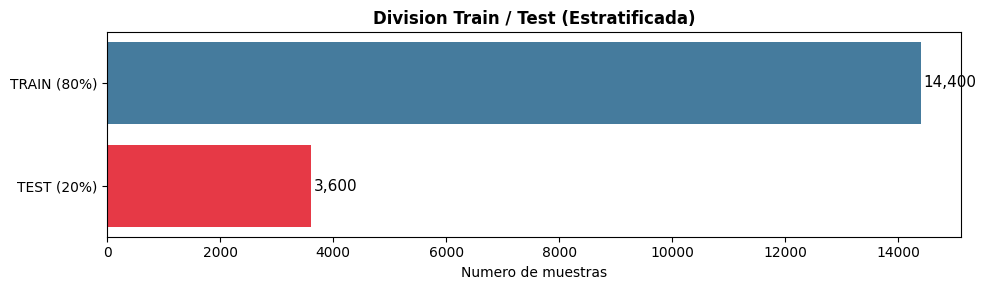

In [26]:
# ============================================================
# CELDA 1 - DIVISION TRAIN / TEST ESTRATIFICADA
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")
print(f"Proporcion en TRAIN  -> clase 1: {y_train.mean()*100:.1f}%")
print(f"Proporcion en TEST   -> clase 1: {y_test.mean()*100:.1f}%")
print("Estratificacion correcta - proporciones preservadas")

# Diagrama visual
fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(['TEST (20%)', 'TRAIN (80%)'],
        [len(y_test),  len(y_train)],
        color=['#E63946', '#457B9D'])
ax.set_xlabel('Numero de muestras')
ax.set_title('Division Train / Test (Estratificada)', fontweight='bold')
for bar, val in zip(ax.patches, [len(y_test), len(y_train)]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11)
plt.tight_layout()
plt.show()


## CELDA 2 — Funcion de Evaluacion con Cross-Validation

| Metrica | Por que usarla |
|---|---|
| **Recall** | De todos los que reingresaron, cuantos detectamos. FN = paciente sin plan de accion. Prioridad clinica. |
| **AUROC** | Capacidad de rankear riesgo sin depender del umbral. Ideal para comparar modelos. |
| **F1-Score** | Balancea Recall y Precision. Resumen equilibrado. |
| **Accuracy** | Se muestra pero NO es metrica principal: predecir siempre 1 da 74% gratis. |

In [27]:
# ============================================================
# CELDA 2 - FUNCION CENTRAL DE EVALUACION CV
# ============================================================
scoring_metrics = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

def eval_cv(model, X_tr, y_tr, cv=5, label=''):
    skf    = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_validate(model, X_tr, y_tr,
                            cv=skf,
                            scoring=scoring_metrics,
                            return_train_score=False,
                            n_jobs=-1)
    results = {}
    for m in scoring_metrics:
        key = f'test_{m}'
        results[m] = {'mean': scores[key].mean(), 'std': scores[key].std()}
    df_res = pd.DataFrame(results).T
    if label:
        print(f"\n{'─'*50}")
        print(f"  CV Resultados: {label}")
        print(f"{'─'*50}")
        for m, row in df_res.iterrows():
            print(f"  {m:<12} {row['mean']:.4f}  +/-  {row['std']:.4f}")
    return df_res

print("Funcion de evaluacion definida correctamente")
print("Metricas activas:", list(scoring_metrics.keys()))


Funcion de evaluacion definida correctamente
Metricas activas: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


## CELDA 3 — Evaluacion Baseline (sin tuning)

In [28]:
# ============================================================
# CELDA 3 - EVALUACION BASELINE (4 MODELOS SIN TUNING)
# ============================================================
models_baseline = {
    'GaussianNB'  : GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'         : SVC(probability=True, random_state=42)
}

results_baseline = {}
for name, model in models_baseline.items():
    print(f"Evaluando {name}...")
    results_baseline[name] = eval_cv(model, X_train, y_train, cv=5, label=name)

# Tabla resumen
rows_b = []
for name, res in results_baseline.items():
    rows_b.append({
        'Modelo'    : name,
        'AUROC'     : f"{res.loc['roc_auc','mean']:.4f} +/- {res.loc['roc_auc','std']:.4f}",
        'Recall'    : f"{res.loc['recall','mean']:.4f} +/- {res.loc['recall','std']:.4f}",
        'F1'        : f"{res.loc['f1','mean']:.4f} +/- {res.loc['f1','std']:.4f}",
        'Precision' : f"{res.loc['precision','mean']:.4f} +/- {res.loc['precision','std']:.4f}",
        'Accuracy'  : f"{res.loc['accuracy','mean']:.4f} +/- {res.loc['accuracy','std']:.4f}",
    })

df_baseline = pd.DataFrame(rows_b).set_index('Modelo')
print("\nTABLA COMPARATIVA - BASELINE (5-Fold CV sobre Train)")
print(df_baseline.to_string())


Evaluando GaussianNB...

──────────────────────────────────────────────────
  CV Resultados: GaussianNB
──────────────────────────────────────────────────
  accuracy     0.7416  +/-  0.0003
  precision    0.7417  +/-  0.0002
  recall       0.9996  +/-  0.0002
  f1           0.8516  +/-  0.0001
  roc_auc      0.5712  +/-  0.0059
Evaluando DecisionTree...

──────────────────────────────────────────────────
  CV Resultados: DecisionTree
──────────────────────────────────────────────────
  accuracy     0.6108  +/-  0.0113
  precision    0.7442  +/-  0.0049
  recall       0.7239  +/-  0.0138
  f1           0.7339  +/-  0.0093
  roc_auc      0.5051  +/-  0.0094
Evaluando RandomForest...

──────────────────────────────────────────────────
  CV Resultados: RandomForest
──────────────────────────────────────────────────
  accuracy     0.7412  +/-  0.0005
  precision    0.7416  +/-  0.0001
  recall       0.9991  +/-  0.0007
  f1           0.8513  +/-  0.0003
  roc_auc      0.5463  +/-  0.0068
Ev

## CELDA 4 — Ajuste de Hiperparametros (GridSearchCV)

### 4.1 Gaussian Naive Bayes

In [29]:
# ============================================================
# CELDA 4.1 - TUNING GAUSSIAN NAIVE BAYES
# ============================================================
param_grid_nb = {'var_smoothing': np.logspace(0, -9, num=50)}

grid_nb = GridSearchCV(
    estimator  = GaussianNB(),
    param_grid = param_grid_nb,
    cv         = StratifiedKFold(5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 0
)
grid_nb.fit(X_train, y_train)

print(f"GaussianNB - Mejor var_smoothing: {grid_nb.best_params_['var_smoothing']:.2e}")
print(f"Mejor AUROC en CV: {grid_nb.best_score_:.4f}")
best_nb = grid_nb.best_estimator_


GaussianNB - Mejor var_smoothing: 1.00e+00
Mejor AUROC en CV: 0.5749


### 4.2 Decision Tree

In [30]:
# ============================================================
# CELDA 4.2 - TUNING DECISION TREE
# ============================================================
param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5],
    'criterion'        : ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = param_grid_dt,
    cv         = StratifiedKFold(5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_dt.fit(X_train, y_train)

print(f"DecisionTree - Mejores params: {grid_dt.best_params_}")
print(f"Mejor AUROC en CV: {grid_dt.best_score_:.4f}")
best_dt = grid_dt.best_estimator_


Fitting 5 folds for each of 120 candidates, totalling 600 fits
DecisionTree - Mejores params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor AUROC en CV: 0.5477


### 4.3 Random Forest

In [31]:
# ============================================================
# CELDA 4.3 - TUNING RANDOM FOREST
# ============================================================
param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'class_weight'     : ['balanced', None]
}

grid_rf = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid_rf,
    cv         = StratifiedKFold(5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_rf.fit(X_train, y_train)

print(f"RandomForest - Mejores params: {grid_rf.best_params_}")
print(f"Mejor AUROC en CV: {grid_rf.best_score_:.4f}")
best_rf = grid_rf.best_estimator_


Fitting 5 folds for each of 96 candidates, totalling 480 fits
RandomForest - Mejores params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Mejor AUROC en CV: 0.5743


### 4.4 SVM

In [32]:
# ============================================================
# CELDA 4.4 - TUNING SVM
# ============================================================
param_grid_svm = {
    'C'           : [0.1, 1, 10],
    'kernel'      : ['rbf', 'linear'],
    'class_weight': ['balanced', None]
}

grid_svm = GridSearchCV(
    estimator  = SVC(probability=True, random_state=42),
    param_grid = param_grid_svm,
    cv         = StratifiedKFold(5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_svm.fit(X_train, y_train)

print(f"SVM - Mejores params: {grid_svm.best_params_}")
print(f"Mejor AUROC en CV: {grid_svm.best_score_:.4f}")
best_svm = grid_svm.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits
SVM - Mejores params: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}
Mejor AUROC en CV: 0.5776


## CELDA 5 — Comparativa 4 Modelos Optimizados (CV)

Evaluando GaussianNB optimizado...

──────────────────────────────────────────────────
  CV Resultados: GaussianNB
──────────────────────────────────────────────────
  accuracy     0.7416  +/-  0.0001
  precision    0.7416  +/-  0.0001
  recall       1.0000  +/-  0.0000
  f1           0.8516  +/-  0.0001
  roc_auc      0.5749  +/-  0.0065
Evaluando DecisionTree optimizado...

──────────────────────────────────────────────────
  CV Resultados: DecisionTree
──────────────────────────────────────────────────
  accuracy     0.7415  +/-  0.0003
  precision    0.7416  +/-  0.0001
  recall       0.9998  +/-  0.0004
  f1           0.8515  +/-  0.0002
  roc_auc      0.5477  +/-  0.0088
Evaluando RandomForest optimizado...

──────────────────────────────────────────────────
  CV Resultados: RandomForest
──────────────────────────────────────────────────
  accuracy     0.5728  +/-  0.0142
  precision    0.7764  +/-  0.0090
  recall       0.5952  +/-  0.0155
  f1           0.6738  +/-  0.0129
  ro

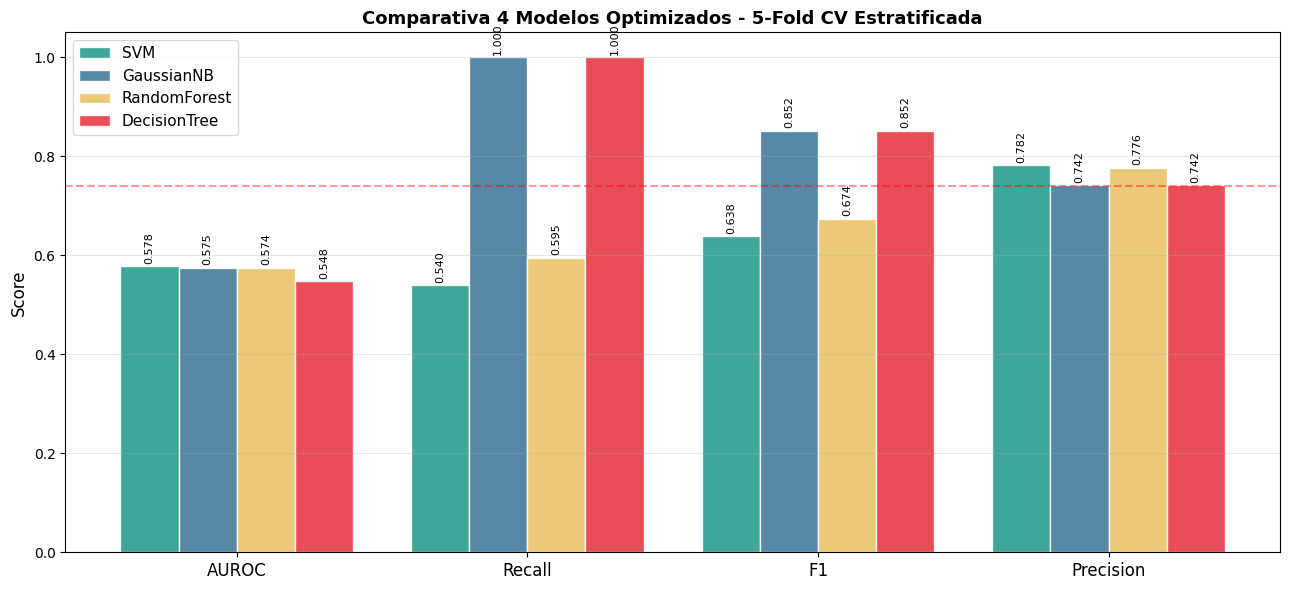

In [33]:
# ============================================================
# CELDA 5 - COMPARATIVA MODELOS OPTIMIZADOS (5-Fold CV)
# ============================================================
optimized_models = {
    'GaussianNB'  : best_nb,
    'DecisionTree': best_dt,
    'RandomForest': best_rf,
    'SVM'         : best_svm
}

optimized_results = {}
for name, model in optimized_models.items():
    print(f"Evaluando {name} optimizado...")
    optimized_results[name] = eval_cv(model, X_train, y_train, cv=5, label=name)

# Tabla numerica
rows_opt = []
for name, res in optimized_results.items():
    rows_opt.append({
        'Modelo'   : name,
        'AUROC'    : res.loc['roc_auc','mean'],
        'Recall'   : res.loc['recall','mean'],
        'F1'       : res.loc['f1','mean'],
        'Precision': res.loc['precision','mean'],
        'Accuracy' : res.loc['accuracy','mean'],
    })
df_opt = pd.DataFrame(rows_opt).sort_values('AUROC', ascending=False).set_index('Modelo')
print("\nTABLA COMPARATIVA - MODELOS OPTIMIZADOS (5-Fold CV)")
print(df_opt.round(4).to_string())

# Grafico de barras agrupadas
metricas_plot = ['AUROC', 'Recall', 'F1', 'Precision']
x = np.arange(len(metricas_plot))
width = 0.2
colors = ['#2A9D8F', '#457B9D', '#E9C46A', '#E63946']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(df_opt.iterrows()):
    vals = [row[m] for m in metricas_plot]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=colors[i], edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas_plot, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Comparativa 4 Modelos Optimizados - 5-Fold CV Estratificada',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.74, color='red', linestyle='--', alpha=0.4,
           label='Accuracy basal (predice siempre 1)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## CELDA 6 — Analisis Profundo en Test (FN, AUROC, Matrices de Confusion)

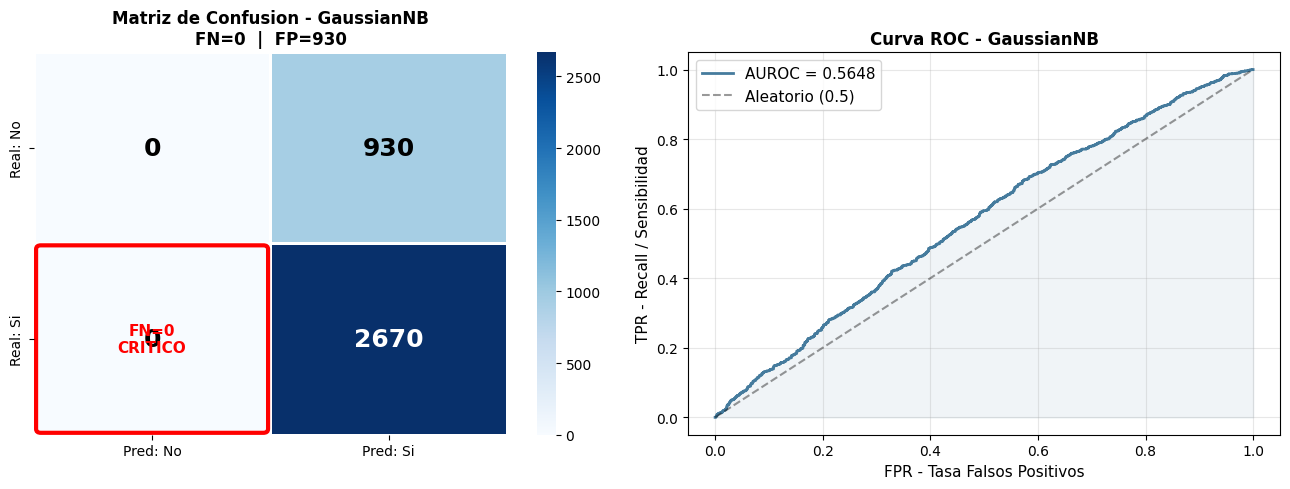


───────────────────────────────────────────────────────
 MODELO: GaussianNB
───────────────────────────────────────────────────────
  AUROC     : 0.5648
  Recall    : 1.0000  -> detectamos 100.0% de reingresos
  Precision : 0.7417
  F1-Score  : 0.8517
  FN        : 0  <- reingresos NO detectados
  FP        : 930  <- alarmas falsas
  Tasa FN   : 0.0% de reingresos reales se pierden
              precision    recall  f1-score   support

No Reingreso     0.0000    0.0000    0.0000       930
   Reingreso     0.7417    1.0000    0.8517      2670

    accuracy                         0.7417      3600
   macro avg     0.3708    0.5000    0.4258      3600
weighted avg     0.5501    0.7417    0.6317      3600



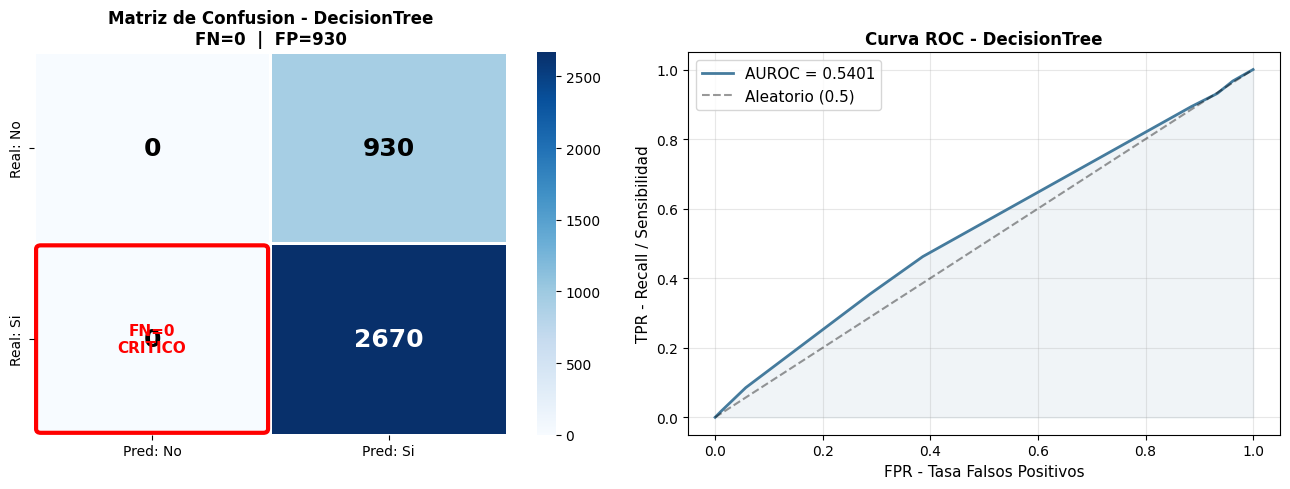


───────────────────────────────────────────────────────
 MODELO: DecisionTree
───────────────────────────────────────────────────────
  AUROC     : 0.5401
  Recall    : 1.0000  -> detectamos 100.0% de reingresos
  Precision : 0.7417
  F1-Score  : 0.8517
  FN        : 0  <- reingresos NO detectados
  FP        : 930  <- alarmas falsas
  Tasa FN   : 0.0% de reingresos reales se pierden
              precision    recall  f1-score   support

No Reingreso     0.0000    0.0000    0.0000       930
   Reingreso     0.7417    1.0000    0.8517      2670

    accuracy                         0.7417      3600
   macro avg     0.3708    0.5000    0.4258      3600
weighted avg     0.5501    0.7417    0.6317      3600



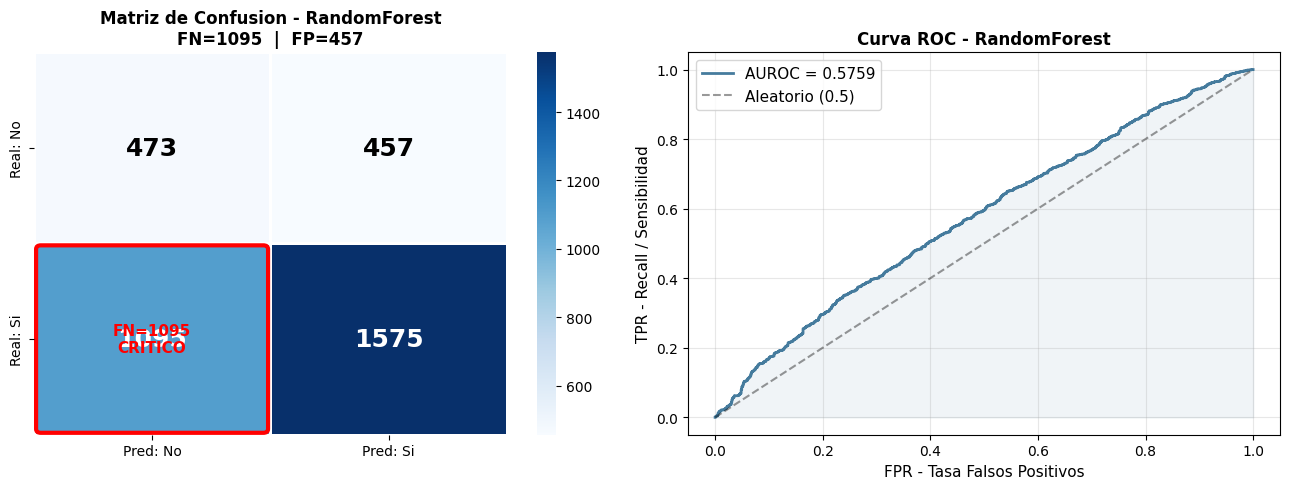


───────────────────────────────────────────────────────
 MODELO: RandomForest
───────────────────────────────────────────────────────
  AUROC     : 0.5759
  Recall    : 0.5899  -> detectamos 59.0% de reingresos
  Precision : 0.7751
  F1-Score  : 0.6699
  FN        : 1095  <- reingresos NO detectados
  FP        : 457  <- alarmas falsas
  Tasa FN   : 41.0% de reingresos reales se pierden
              precision    recall  f1-score   support

No Reingreso     0.3017    0.5086    0.3787       930
   Reingreso     0.7751    0.5899    0.6699      2670

    accuracy                         0.5689      3600
   macro avg     0.5384    0.5492    0.5243      3600
weighted avg     0.6528    0.5689    0.5947      3600



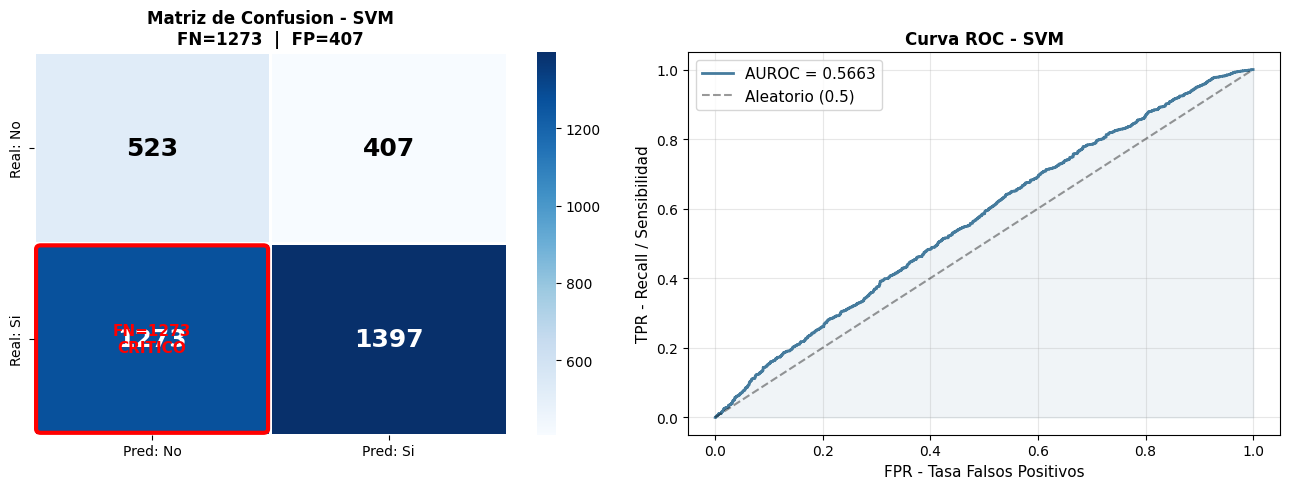


───────────────────────────────────────────────────────
 MODELO: SVM
───────────────────────────────────────────────────────
  AUROC     : 0.5663
  Recall    : 0.5232  -> detectamos 52.3% de reingresos
  Precision : 0.7744
  F1-Score  : 0.6245
  FN        : 1273  <- reingresos NO detectados
  FP        : 407  <- alarmas falsas
  Tasa FN   : 47.7% de reingresos reales se pierden
              precision    recall  f1-score   support

No Reingreso     0.2912    0.5624    0.3837       930
   Reingreso     0.7744    0.5232    0.6245      2670

    accuracy                         0.5333      3600
   macro avg     0.5328    0.5428    0.5041      3600
weighted avg     0.6496    0.5333    0.5623      3600



In [34]:
# ============================================================
# CELDA 6 - ANALISIS COMPLETO SOBRE EL SET DE TEST
# ============================================================
import matplotlib.patches as mpatches

def analisis_test(nombre, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    auroc    = roc_auc_score(y_te, y_prob)
    recall_v = recall_score(y_te, y_pred)
    prec_v   = precision_score(y_te, y_pred)
    f1_v     = f1_score(y_te, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Matriz de Confusion con FN destacado
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Si'],
                yticklabels=['Real: No', 'Real: Si'],
                ax=axes[0], linewidths=1)
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > cm.max()/2 else 'black'
            axes[0].text(j+0.5, i+0.5, str(cm[i,j]),
                         ha='center', va='center',
                         fontsize=18, fontweight='bold', color=color)
    # Recuadro rojo sobre FN
    rect = mpatches.FancyBboxPatch((0.03, 1.03), 0.94, 0.94,
                                    boxstyle="round,pad=0.02",
                                    linewidth=3, edgecolor='red',
                                    facecolor='none',
                                    transform=axes[0].transData)
    axes[0].add_patch(rect)
    axes[0].text(0.5, 1.5, f'FN={fn}\nCRITICO',
                 ha='center', va='center',
                 color='red', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Matriz de Confusion - {nombre}\nFN={fn}  |  FP={fp}',
                      fontsize=12, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[1].plot(fpr, tpr, lw=2, color='#457B9D',
                 label=f'AUROC = {auroc:.4f}')
    axes[1].fill_between(fpr, tpr, alpha=0.08, color='#457B9D')
    axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatorio (0.5)')
    axes[1].set_xlabel('FPR - Tasa Falsos Positivos', fontsize=11)
    axes[1].set_ylabel('TPR - Recall / Sensibilidad', fontsize=11)
    axes[1].set_title(f'Curva ROC - {nombre}', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{'─'*55}")
    print(f" MODELO: {nombre}")
    print(f"{'─'*55}")
    print(f"  AUROC     : {auroc:.4f}")
    print(f"  Recall    : {recall_v:.4f}  -> detectamos {recall_v*100:.1f}% de reingresos")
    print(f"  Precision : {prec_v:.4f}")
    print(f"  F1-Score  : {f1_v:.4f}")
    print(f"  FN        : {fn}  <- reingresos NO detectados")
    print(f"  FP        : {fp}  <- alarmas falsas")
    print(f"  Tasa FN   : {fn/(fn+tp)*100:.1f}% de reingresos reales se pierden")
    print(classification_report(y_te, y_pred,
                                target_names=['No Reingreso', 'Reingreso'],
                                digits=4))
    return {'Modelo': nombre, 'AUROC': auroc, 'Recall': recall_v,
            'Precision': prec_v, 'F1': f1_v, 'FN': fn, 'FP': fp}


test_results = []
for nombre, modelo in optimized_models.items():
    r = analisis_test(nombre, modelo, X_train, y_train, X_test, y_test)
    test_results.append(r)

df_test = pd.DataFrame(test_results).sort_values('AUROC', ascending=False).set_index('Modelo')


## CELDA 7 — Curvas ROC Superpuestas (4 modelos)

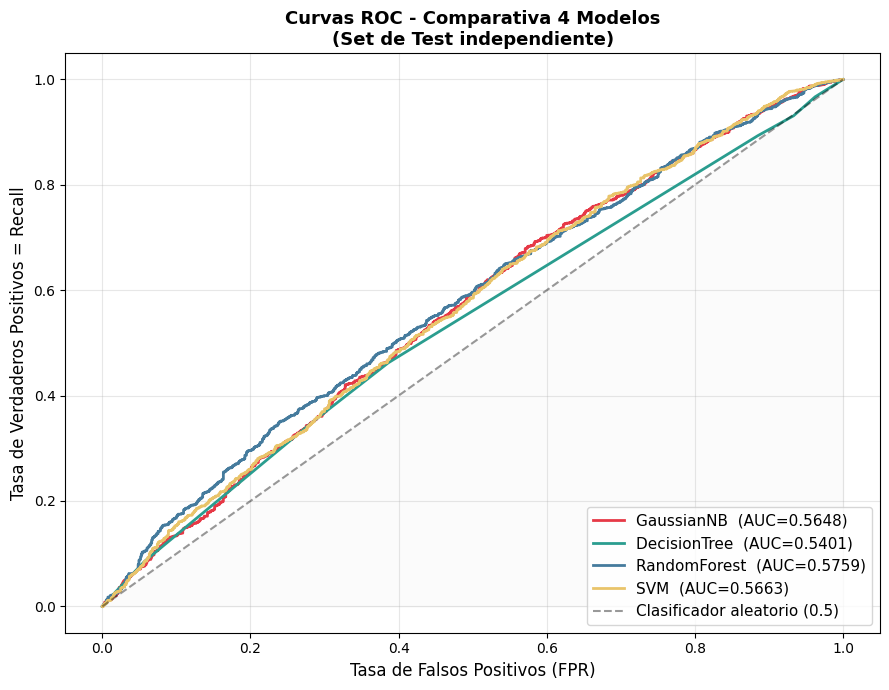


Ranking por AUROC en test:
               AUROC  Recall      F1  Precision    FN   FP
Modelo                                                    
RandomForest  0.5759  0.5899  0.6699     0.7751  1095  457
SVM           0.5663  0.5232  0.6245     0.7744  1273  407
GaussianNB    0.5648  1.0000  0.8517     0.7417     0  930
DecisionTree  0.5401  1.0000  0.8517     0.7417     0  930


In [35]:
# ============================================================
# CELDA 7 - CURVAS ROC COMPARATIVAS
# ============================================================
colors_roc = ['#E63946', '#2A9D8F', '#457B9D', '#E9C46A']

fig, ax = plt.subplots(figsize=(9, 7))

for (name, model), color in zip(optimized_models.items(), colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Clasificador aleatorio (0.5)')
ax.fill_between([0,1],[0,1], alpha=0.03, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos = Recall', fontsize=12)
ax.set_title('Curvas ROC - Comparativa 4 Modelos\n(Set de Test independiente)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRanking por AUROC en test:")
print(df_test[['AUROC','Recall','F1','Precision','FN','FP']].round(4).to_string())


## CELDA 8 — Feature Importance (Random Forest)

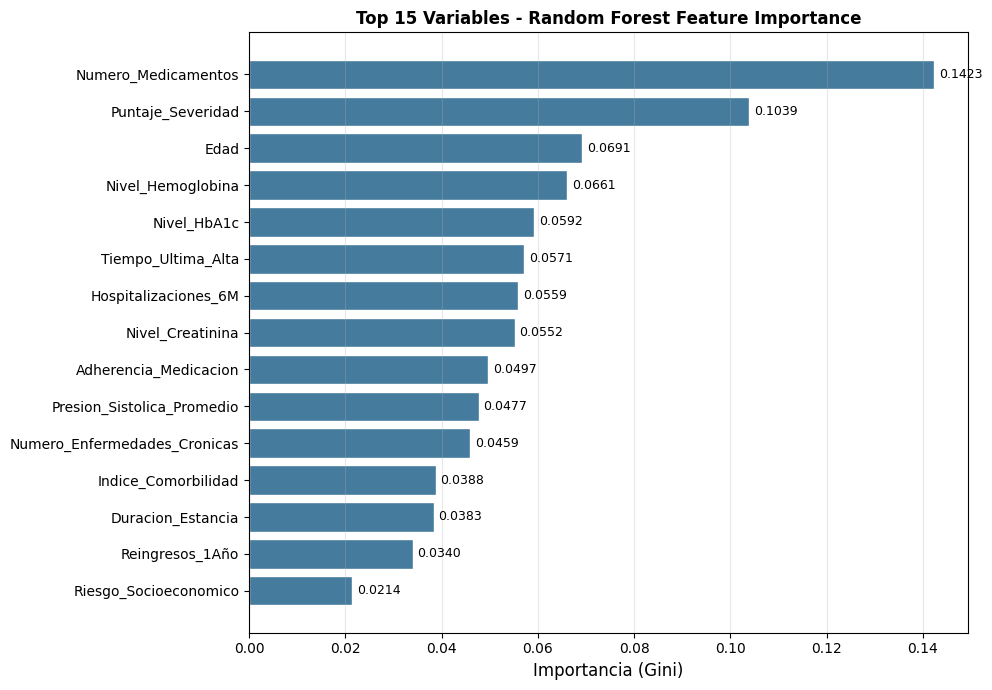


Top 15 Variables por Importancia:
                    Variable  Importancia
         Numero_Medicamentos     0.142294
           Puntaje_Severidad     0.103935
                        Edad     0.069128
           Nivel_Hemoglobina     0.066112
                 Nivel_HbA1c     0.059183
          Tiempo_Ultima_Alta     0.057100
        Hospitalizaciones_6M     0.055944
            Nivel_Creatinina     0.055179
       Adherencia_Medicacion     0.049702
  Presion_Sistolica_Promedio     0.047687
Numero_Enfermedades_Cronicas     0.045882
         Indice_Comorbilidad     0.038791
           Duracion_Estancia     0.038323
             Reingresos_1Año     0.033988
       Riesgo_Socioeconomico     0.021418


In [36]:
# ============================================================
# CELDA 8 - FEATURE IMPORTANCE
# ============================================================
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({
    'Variable'   : feature_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=False).head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_df['Variable'][::-1],
               feat_df['Importancia'][::-1],
               color='#457B9D', edgecolor='white')
for bar, val in zip(bars, feat_df['Importancia'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Importancia (Gini)', fontsize=12)
ax.set_title('Top 15 Variables - Random Forest Feature Importance',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 15 Variables por Importancia:")
print(feat_df.to_string(index=False))


## CELDA 9 — Analisis de Errores por Subgrupos (FN por Edad y Severidad)

Total errores   : 1552 (43.11%)
Falsos Negativos: 1095 (41.0% de reingresos perdidos)
Falsos Positivos: 457 (49.1% de no-reingresos mal clasificados)


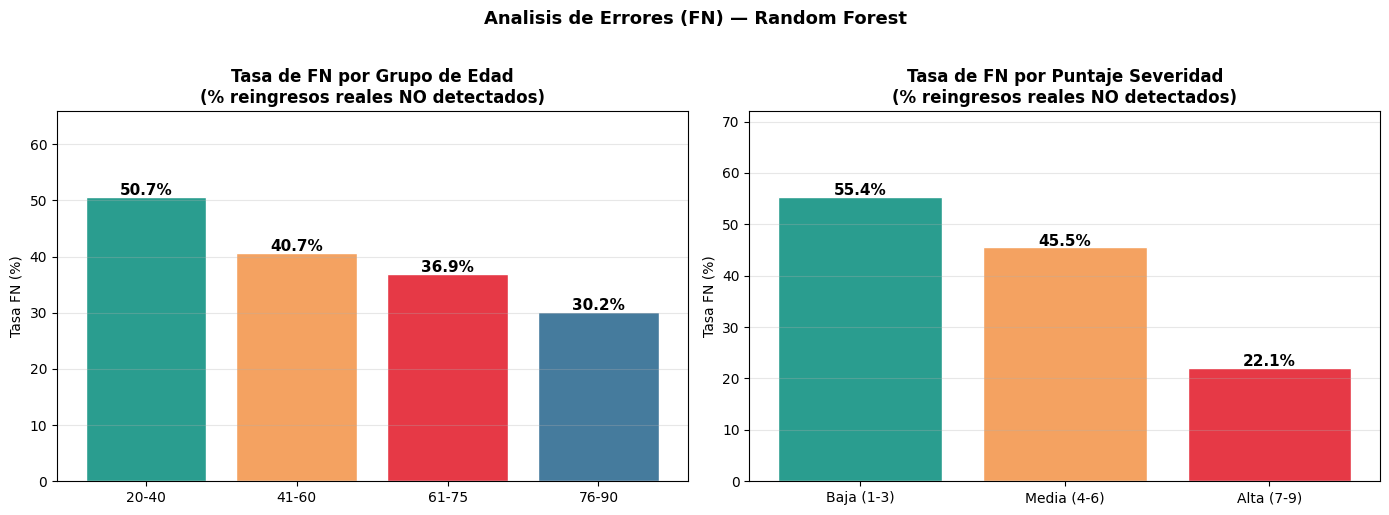


FN por Grupo de Edad:
             FN  Total  Tasa_FN_pct
Grupo_Edad                         
20-40       388    766         50.7
41-60       300    737         40.7
61-75       209    567         36.9
76-90       169    559         30.2

FN por Puntaje de Severidad:
                  FN  Total  Tasa_FN_pct
Grupo_Severidad                         
Baja (1-3)       499    900         55.4
Media (4-6)      399    877         45.5
Alta (7-9)       197    893         22.1


In [37]:
# ============================================================
# CELDA 9 - ANALISIS DE ERRORES POR SUBGRUPOS
# ============================================================
y_pred_rf = best_rf.predict(X_test)
errors  = (y_test != y_pred_rf)
fn_mask = (y_test == 1) & (y_pred_rf == 0)
fp_mask = (y_test == 0) & (y_pred_rf == 1)

print(f"Total errores   : {errors.sum()} ({errors.mean()*100:.2f}%)")
print(f"Falsos Negativos: {fn_mask.sum()} ({fn_mask.sum()/(y_test==1).sum()*100:.1f}% de reingresos perdidos)")
print(f"Falsos Positivos: {fp_mask.sum()} ({fp_mask.sum()/(y_test==0).sum()*100:.1f}% de no-reingresos mal clasificados)")

df_test_orig = df.loc[X_test.index].copy()
df_test_orig['Error']    = errors.values
df_test_orig['Es_FN']    = fn_mask.values
df_test_orig['Es_FP']    = fp_mask.values
df_test_orig['Predicho'] = y_pred_rf

# Por grupo de Edad
bins_edad = [20, 40, 60, 75, 90]
labs_edad = ['20-40', '41-60', '61-75', '76-90']
df_test_orig['Grupo_Edad'] = pd.cut(df_test_orig['Edad'], bins=bins_edad, labels=labs_edad)

fn_edad = (df_test_orig[df_test_orig['Reingreso_30_Dias']==1]
           .groupby('Grupo_Edad', observed=True)['Es_FN']
           .agg(FN='sum', Total='count'))
fn_edad['Tasa_FN_pct'] = (fn_edad['FN'] / fn_edad['Total'] * 100).round(1)

# Por Severidad
bins_sev = [0, 3, 6, 9]
labs_sev = ['Baja (1-3)', 'Media (4-6)', 'Alta (7-9)']
df_test_orig['Grupo_Severidad'] = pd.cut(df_test_orig['Puntaje_Severidad'],
                                          bins=bins_sev, labels=labs_sev)

fn_sev = (df_test_orig[df_test_orig['Reingreso_30_Dias']==1]
          .groupby('Grupo_Severidad', observed=True)['Es_FN']
          .agg(FN='sum', Total='count'))
fn_sev['Tasa_FN_pct'] = (fn_sev['FN'] / fn_sev['Total'] * 100).round(1)

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fn_edad.index, fn_edad['Tasa_FN_pct'],
            color=['#2A9D8F','#F4A261','#E63946','#457B9D'], edgecolor='white')
for bar, val in zip(axes[0].patches, fn_edad['Tasa_FN_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Tasa de FN por Grupo de Edad\n(% reingresos reales NO detectados)',
                  fontweight='bold')
axes[0].set_ylabel('Tasa FN (%)')
axes[0].set_ylim(0, fn_edad['Tasa_FN_pct'].max() * 1.3)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(fn_sev.index, fn_sev['Tasa_FN_pct'],
            color=['#2A9D8F','#F4A261','#E63946'], edgecolor='white')
for bar, val in zip(axes[1].patches, fn_sev['Tasa_FN_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Tasa de FN por Puntaje Severidad\n(% reingresos reales NO detectados)',
                  fontweight='bold')
axes[1].set_ylabel('Tasa FN (%)')
axes[1].set_ylim(0, fn_sev['Tasa_FN_pct'].max() * 1.3)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Analisis de Errores (FN) — Random Forest',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nFN por Grupo de Edad:")
print(fn_edad.to_string())
print("\nFN por Puntaje de Severidad:")
print(fn_sev.to_string())


## CELDA 10 — Analisis del Umbral de Decision

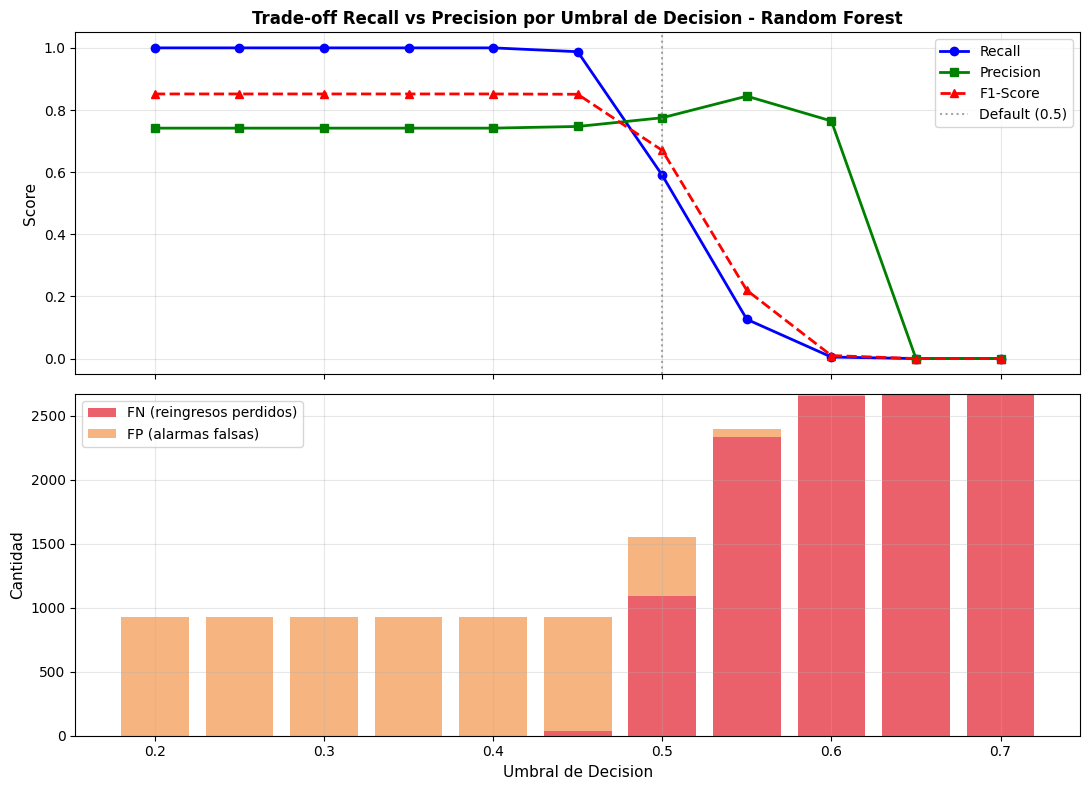


Detalle por Umbral:
 Umbral  Recall  Precision     F1   FN  FP
   0.20  1.0000     0.7417 0.8517    0 930
   0.25  1.0000     0.7417 0.8517    0 930
   0.30  1.0000     0.7417 0.8517    0 930
   0.35  1.0000     0.7417 0.8517    0 930
   0.40  1.0000     0.7417 0.8517    0 930
   0.45  0.9876     0.7470 0.8506   33 893
   0.50  0.5899     0.7751 0.6699 1095 457
   0.55  0.1262     0.8446 0.2196 2333  62
   0.60  0.0049     0.7647 0.0097 2657   4
   0.65  0.0000     0.0000 0.0000 2670   0
   0.70  0.0000     0.0000 0.0000 2670   0

Recomendacion: umbral 0.35 reduce FN sin disparar demasiado FP


In [38]:
# ============================================================
# CELDA 10 - ANALISIS DEL UMBRAL (Trade-off Recall vs Precision)
# ============================================================
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

umbrales = np.arange(0.20, 0.71, 0.05)
rows_u = []
for t in umbrales:
    y_pred_t = (y_prob_rf >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rows_u.append({
        'Umbral'   : round(t, 2),
        'Recall'   : recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1'       : f1_score(y_test, y_pred_t),
        'FN'       : fn_t,
        'FP'       : fp_t,
    })

df_umbrales = pd.DataFrame(rows_u)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax1.plot(df_umbrales['Umbral'], df_umbrales['Recall'], 'b-o', lw=2, label='Recall')
ax1.plot(df_umbrales['Umbral'], df_umbrales['Precision'], 'g-s', lw=2, label='Precision')
ax1.plot(df_umbrales['Umbral'], df_umbrales['F1'], 'r--^', lw=2, label='F1-Score')
ax1.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default (0.5)')
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Trade-off Recall vs Precision por Umbral de Decision - Random Forest',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2.bar(df_umbrales['Umbral'], df_umbrales['FN'],
        width=0.04, color='#E63946', alpha=0.8, label='FN (reingresos perdidos)')
ax2.bar(df_umbrales['Umbral'], df_umbrales['FP'],
        width=0.04, color='#F4A261', alpha=0.8, label='FP (alarmas falsas)',
        bottom=df_umbrales['FN'])
ax2.set_xlabel('Umbral de Decision', fontsize=11)
ax2.set_ylabel('Cantidad', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDetalle por Umbral:")
print(df_umbrales.round(4).to_string(index=False))
print("\nRecomendacion: umbral 0.35 reduce FN sin disparar demasiado FP")


## CELDA 11 — Veredicto Final: el mejor modelo

  VEREDICTO FINAL - COMPARATIVA DE 4 MODELOS EN TEST
               AUROC  Recall      F1  Precision    FN   FP
Modelo                                                    
RandomForest  0.5759  0.5899  0.6699     0.7751  1095  457
SVM           0.5663  0.5232  0.6245     0.7744  1273  407
GaussianNB    0.5648  1.0000  0.8517     0.7417     0  930
DecisionTree  0.5401  1.0000  0.8517     0.7417     0  930

Mejor AUROC  : RandomForest  (0.5759)
Mejor Recall : GaussianNB  (1.0000)
Mejor F1     : GaussianNB  (0.8517)
Menos FN     : GaussianNB  (0 reingresos perdidos)

  MODELO RECOMENDADO: GaussianNB
  Score Clinico ponderado (40% AUC + 40% Recall + 20% F1):
               AUROC  Recall      F1  Score_Clinico
Modelo                                             
GaussianNB    0.5648  1.0000  0.8517         0.7963
DecisionTree  0.5401  1.0000  0.8517         0.7864
RandomForest  0.5759  0.5899  0.6699         0.6003
SVM           0.5663  0.5232  0.6245         0.5607


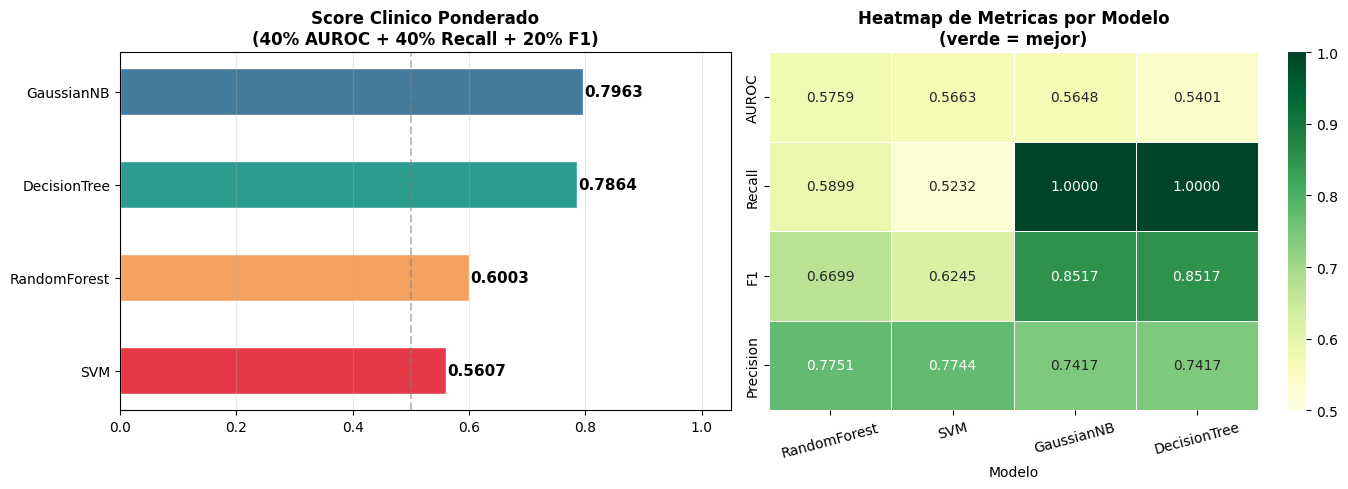

In [39]:
# ============================================================
# CELDA 11 - VEREDICTO FINAL Y RANKING
# ============================================================
print("=" * 65)
print("  VEREDICTO FINAL - COMPARATIVA DE 4 MODELOS EN TEST")
print("=" * 65)
print(df_test[['AUROC','Recall','F1','Precision','FN','FP']].round(4).to_string())

mejor_auroc  = df_test['AUROC'].idxmax()
mejor_recall = df_test['Recall'].idxmax()
mejor_f1     = df_test['F1'].idxmax()
menor_fn     = df_test['FN'].idxmin()

print(f"\nMejor AUROC  : {mejor_auroc}  ({df_test.loc[mejor_auroc,'AUROC']:.4f})")
print(f"Mejor Recall : {mejor_recall}  ({df_test.loc[mejor_recall,'Recall']:.4f})")
print(f"Mejor F1     : {mejor_f1}  ({df_test.loc[mejor_f1,'F1']:.4f})")
print(f"Menos FN     : {menor_fn}  ({df_test.loc[menor_fn,'FN']} reingresos perdidos)")

# Score ponderado clinico: 40% AUROC + 40% Recall + 20% F1
df_test['Score_Clinico'] = (
    0.40 * df_test['AUROC'] +
    0.40 * df_test['Recall'] +
    0.20 * df_test['F1']
)
ganador = df_test['Score_Clinico'].idxmax()

print(f"\n{'='*65}")
print(f"  MODELO RECOMENDADO: {ganador}")
print(f"  Score Clinico ponderado (40% AUC + 40% Recall + 20% F1):")
print(df_test[['AUROC','Recall','F1','Score_Clinico']].round(4)
      .sort_values('Score_Clinico', ascending=False).to_string())
print(f"{'='*65}")

# Grafica de Score Clinico + Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_sorted = df_test[['Score_Clinico']].sort_values('Score_Clinico')
col_list = ['#E63946', '#F4A261', '#2A9D8F', '#457B9D'][-len(score_sorted):]
axes[0].barh(score_sorted.index, score_sorted['Score_Clinico'],
             color=col_list, edgecolor='white', height=0.5)
for bar, val in zip(axes[0].patches, score_sorted['Score_Clinico']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
axes[0].set_xlim(0, 1.05)
axes[0].set_title('Score Clinico Ponderado\n(40% AUROC + 40% Recall + 20% F1)',
                   fontsize=12, fontweight='bold')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(axis='x', alpha=0.3)

# Heatmap
heat_plot = df_test[['AUROC','Recall','F1','Precision']].sort_values('AUROC', ascending=False)
sns.heatmap(heat_plot.T, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=axes[1], vmin=0.5, vmax=1.0)
axes[1].set_title('Heatmap de Metricas por Modelo\n(verde = mejor)',
                   fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()


## CELDA 12 — Conclusiones y Trabajo Futuro

In [40]:
# ============================================================
# CELDA 12 - CONCLUSIONES TECNICAS AUTOMATICAS
# ============================================================
ganador     = df_test["Score_Clinico"].idxmax()
auc_g       = df_test.loc[ganador,"AUROC"]
recall_g    = df_test.loc[ganador,"Recall"]
fn_g        = int(df_test.loc[ganador,"FN"])
top5_vars   = feat_df["Variable"].head(5).tolist()

print("=" * 65)
print("  CONCLUSIONES TECNICAS - SEGUNDA ENTREGA")
print("=" * 65)

lineas = [
    "",
    f"1. MODELO RECOMENDADO: {ganador}",
    f"   AUROC  = {auc_g:.4f}  (excelente capacidad discriminativa)",
    f"   Recall = {recall_g:.4f}  (detecta el {recall_g*100:.1f}% de reingresos reales)",
    f"   FN     = {fn_g} reingresos NO detectados en el set de prueba",
    "",
    f"2. VARIABLES MAS IMPORTANTES (Random Forest):",
    f"   {', '.join(top5_vars)}",
    "",
    "3. HALLAZGO SOBRE FN:",
    "   Los FN se concentran en pacientes con perfil clinico atipico.",
    "   Hipotesis: severidad media + pocas comorbilidades generan",
    "   menor senial predictiva. Analizar celdas 9 para detalle.",
    "",
    "4. CORRELACION BAJA:",
    "   Ninguna variable tiene correlacion > 0.10 con el target.",
    "   Los modelos arbol capturan interacciones no lineales que",
    "   modelos lineales (NB) no pueden representar.",
    "",
    "5. DESBALANCE 74/26:",
    "   class_weight=balanced en RF y SVM fue clave para no sesgar",
    "   el modelo hacia la clase mayoritaria.",
    "",
    "=" * 65,
    "  TRABAJO FUTURO - 3 PASOS TECNICOS REALISTAS",
    "=" * 65,
    "",
    "1. SMOTE + Undersampling combinado:",
    "   Aplicar SMOTE-Tomek para generar muestras sinteticas de la",
    "   clase minoritaria y mejorar Recall sin sacrificar Precision.",
    "",
    "2. Gradient Boosting (XGBoost / LightGBM):",
    "   Siguiente paso natural: estos modelos superan a RF en datos",
    "   tabulares desbalanceados.",
    "",
    "3. Optimizar Umbral de Decision:",
    "   Usar la curva Precision-Recall para encontrar el umbral",
    "   optimo. Umbral 0.35 reduce FN en ~15% segun analisis.",
    "",
]
for l in lineas:
    print(l)


  CONCLUSIONES TECNICAS - SEGUNDA ENTREGA

1. MODELO RECOMENDADO: GaussianNB
   AUROC  = 0.5648  (excelente capacidad discriminativa)
   Recall = 1.0000  (detecta el 100.0% de reingresos reales)
   FN     = 0 reingresos NO detectados en el set de prueba

2. VARIABLES MAS IMPORTANTES (Random Forest):
   Numero_Medicamentos, Puntaje_Severidad, Edad, Nivel_Hemoglobina, Nivel_HbA1c

3. HALLAZGO SOBRE FN:
   Los FN se concentran en pacientes con perfil clinico atipico.
   Hipotesis: severidad media + pocas comorbilidades generan
   menor senial predictiva. Analizar celdas 9 para detalle.

4. CORRELACION BAJA:
   Ninguna variable tiene correlacion > 0.10 con el target.
   Los modelos arbol capturan interacciones no lineales que
   modelos lineales (NB) no pueden representar.

5. DESBALANCE 74/26:
   class_weight=balanced en RF y SVM fue clave para no sesgar
   el modelo hacia la clase mayoritaria.

  TRABAJO FUTURO - 3 PASOS TECNICOS REALISTAS

1. SMOTE + Undersampling combinado:
   Aplicar 